In [2]:
#from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd
import seaborn as sns

In [4]:
path = '.\\test\\gA_1_s1_ir_face_mp4-26_jpg.rf.8073bccb5c613d34b8f058da71adc5d8.jpg'
image =plt.imread(path)
plt.imshow(image)
print(image.shape)

FileNotFoundError: [Errno 2] No such file or directory: '.\\test\\gA_1_s1_ir_face_mp4-26_jpg.rf.8073bccb5c613d34b8f058da71adc5d8.jpg'

In [26]:
# Load Test data.
test_images = []
train_images = []
train_labels = []
test_labels = []
with open(".\\test\\_annotations.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        line = line.strip().split(" ")
        fname = line[0]
        label = int(line[1].split(",")[-1])
        image = plt.imread(f".\\test\\{fname}")
        test_images.append(image)
        test_labels.append(label)
with open(".\\train\\_annotations.txt", "r") as f:
    lines = f.readlines()[:1000]
    for line in lines:
        try:
          line = line.strip().split(" ")
          fname = line[0]
          label = int(line[1].split(",")[-1])
          image = plt.imread(f".\\train\\{fname}")
          train_images.append(image)
          train_labels.append(label)
        except:
          pass
test_images = np.array(test_images)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
train_images = np.array(train_images)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19324\2472277819.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(test_labels)


3    412
0    301
1    152
4     69
5     26
2     25
Name: count, dtype: int64

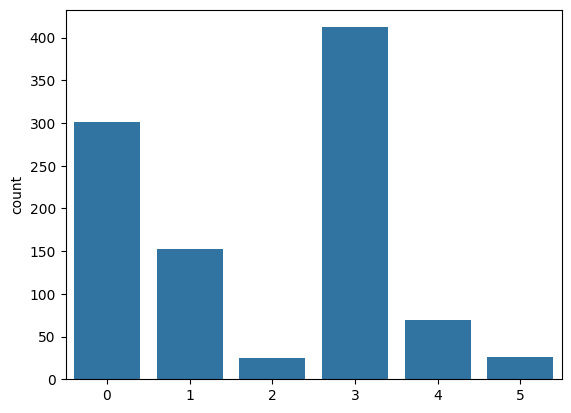

In [4]:
sns.countplot(x=test_labels)

pd.value_counts(test_labels)

C:\Users\Admin\AppData\Local\Temp\ipykernel_19324\1338992618.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(train_labels)


3    4969
0    3732
1    1676
4     785
5     439
2     347
Name: count, dtype: int64

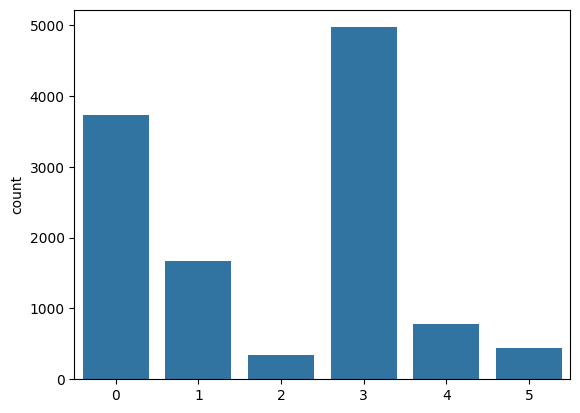

In [5]:
sns.countplot(x=train_labels)

pd.value_counts(train_labels)

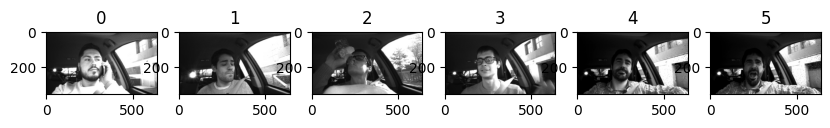

In [6]:
#0 = DangerousDriving
#1 = Distracted
#2 = Drinking
#3 = SafeDriving
#4 = SleepyDriving
#5 = Yawn



fig, ax = plt.subplots(ncols=6, figsize = (10,10))
img_types = [0, 1, 2, 3, 4, 5]

for label in range(len(img_types)):
  locations = np.where(test_labels == img_types[label])
  ax[label].imshow(test_images[locations[0][0]])
  ax[label].title.set_text(img_types[label])

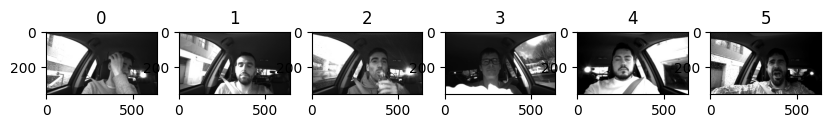

In [7]:
fig, ax = plt.subplots(ncols=6, figsize = (10,10))
img_types = [0, 1, 2, 3, 4, 5]

for label in range(len(img_types)):
  locations = np.where(train_labels == img_types[label])
  ax[label].imshow(train_images[locations[0][0]])
  ax[label].title.set_text(img_types[label])

In [8]:
# Convert to grayscale.
test_gray_images = []
for img in test_images:
   test_gray_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
test_gray_images = np.array(test_gray_images)

In [9]:
train_gray_images = []
for img in train_images:
   train_gray_images.append(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY))
train_gray_images = np.array(train_gray_images)

In [10]:
print(test_gray_images.shape)
print(train_gray_images.shape)

(985, 360, 640)
(11948, 360, 640)


In [11]:
def normalize_one_image(image):
  return (image - np.min(image)) / (np.max(image) - np.min(image))
test_normalized_images = []
for img in test_gray_images:
  test_normalized_images.append(normalize_one_image(img))
test_normalized_images = np.array(test_normalized_images)

In [14]:
train_normalized_images = []
for img in train_gray_images:
  train_normalized_images.append(normalize_one_image(img))
train_normalized_images = np.array(train_normalized_images)

In [15]:
one_hot_labels = []
img_types = [0, 1, 2, 3, 4, 5]
for label in range(len(img_types)):
  new_label = np.zeros(6)
  new_label[img_types.index(label)] = 1
  one_hot_labels.append(new_label)

one_hot_labels = np.array(one_hot_labels)

In [16]:
print(one_hot_labels)

[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]


In [17]:
#one_dim_data = np.reshape(normalized_images, (985, 360* 640))
test_one_dim_data = np.reshape(test_normalized_images, (test_normalized_images.shape[0], test_normalized_images.shape[1]* test_normalized_images.shape[2]))

In [18]:
train_one_dim_data = np.reshape(train_normalized_images, (train_normalized_images.shape[0], train_normalized_images.shape[1]* train_normalized_images.shape[2]))

In [19]:
print(train_one_dim_data.shape)
print(test_one_dim_data.shape)


(11948, 230400)
(985, 230400)


In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, confusion_matrix

lr = LogisticRegression(max_iter=10, random_state=42)
lr.fit(train_one_dim_data, train_labels)

y_pred = lr.predict(test_one_dim_data)
accuracy = accuracy_score(test_labels, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Metrics
print("Confusion Matrix:")
cm = confusion_matrix(test_labels, y_pred)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred, average='weighted'))
print("Recall:", recall_score(test_labels, y_pred, average='weighted'))
print("F1 Score:", f1_score(test_labels, y_pred, average='weighted'))



C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Accuracy: 0.6426


In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(train_one_dim_data, train_labels)

y_pred = rf.predict(test_one_dim_data)
accuracy = accuracy_score(test_labels, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Metrics
print("Confusion Matrix:")
cm = confusion_matrix(test_labels, y_pred)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred, average='weighted'))
print("Recall:", recall_score(test_labels, y_pred, average='weighted'))
print("F1 Score:", f1_score(test_labels, y_pred, average='weighted'))



Accuracy: 0.9005


In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, max_depth=3)
dt.fit(train_one_dim_data, train_labels)

y_pred = dt.predict(test_one_dim_data)
accuracy = accuracy_score(test_labels, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Metrics
print("Confusion Matrix:")
cm = confusion_matrix(test_labels, y_pred)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred, average='weighted'))
print("Recall:", recall_score(test_labels, y_pred, average='weighted'))
print("F1 Score:", f1_score(test_labels, y_pred, average='weighted'))



Accuracy: 0.6244


In [ ]:
# Support Vector Classifier
from sklearn.svm import SVC

dt = SVC(kernel='linear')
dt.fit(train_one_dim_data, train_labels)

y_pred = dt.predict(test_one_dim_data)
accuracy = accuracy_score(test_labels, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Metrics
print("Confusion Matrix:")
cm = confusion_matrix(test_labels, y_pred)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=np.unique(test_labels), yticklabels=np.unique(test_labels))
plt.title("SVC - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(test_labels, y_pred))
print("Precision:", precision_score(test_labels, y_pred, average='weighted'))
print("Recall:", recall_score(test_labels, y_pred, average='weighted'))
print("F1 Score:", f1_score(test_labels, y_pred, average='weighted'))



Accuracy: 0.8518
